# Extension with Stylistic Diversity (D_style)

- Based on a compact stylometric feature vector (11 features), following classical stylometry/authorship-analysis tradition (Burrows' Delta lineage)

- Captures *how* a text sounds (tone, register, rhythm) rather than *what* it says (D_sem), *which words* are used (D_lex), *how sentences are built* grammatically (D_syn)

**Features:**
1. Function-word frequency distribution (cosine distance over the NLTK English stopword list, Bird, Klein & Loper 2009; n=124 after removing contraction-splitting artifacts)
2. Mean sentence length
3. Sentence length variance (rhythm / burstiness)
4. Flesch Reading Ease
5. Comma density (commas per sentence)
6. Adjective + adverb-to-content-word ratio (via spaCy POS tags)
7. Mean word length in syllables
8. Dialogue ratio (dialogue turns per sentence)
9. Punctuation expressivity (?, !, ellipses per sentence)
10. Mean paragraph length (words per paragraph)
11. Sentence-initial pronoun ratio

**Metric formula:**
$$D_{\text{style}} = \frac{1}{\binom{n}{2}} \sum_{i < j} \| \mathbf{z}_i - \mathbf{z}_j \|_2$$
where $\mathbf{z}_i$ is the z-standardized stylistic feature vector of text $i$.

In [45]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.spatial.distance import cosine
from scipy.stats import kruskal, mannwhitneyu
import spacy
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
import textstat
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources (stopwords)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# Load spaCy model
nlp = spacy.load('en_core_web_sm')


In [46]:
# Configuration
MIN_SENTENCES = 3           # minimum sentences required to include a text
TASK_FILTER = 'storytelling'

SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']

# Function-word set: NLTK's English stopword list (Bird, Klein & Loper, 2009) —
# Restricted to standalone alphabetic entries; this also drops
_CONTRACTION_FRAGMENTS = {
    'ain', 'aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven',
    'isn', 'mightn', 'mustn', 'needn', 'shan', 'shouldn', 'wasn', 'weren',
    'won', 'wouldn', 'd', 'll', 'm', 'ma', 'o', 're', 's', 't', 've', 'y',
}
FUNCTION_WORDS = sorted(
    w for w in stopwords.words('english')
    if w.isalpha() and w not in _CONTRACTION_FRAGMENTS
)

print("Configuration:")
print(f"  Function word set size: {len(FUNCTION_WORDS)}")
print(f"  Min sentences:          {MIN_SENTENCES}")
print(f"  Task filter:            {TASK_FILTER}")


Configuration:
  Function word set size: 124
  Min sentences:          3
  Task filter:            storytelling


## Load Dataset

In [47]:
import json
from pathlib import Path

N_PROMPTS = 100
DATA_DIR = Path('../../data/human_drift/clean_generations')

rows = []
for source in SOURCES:
    fp = DATA_DIR / f'{source}_storytelling_clean.json'
    with open(fp) as f:
        raw = json.load(f)
    prompts = list(raw.keys())[:N_PROMPTS]
    for prompt_id, prompt_key in enumerate(prompts):
        for story_id, text in enumerate(raw[prompt_key]):
            rows.append({
                'prompt_id': prompt_id,
                'source': source,
                'story_id': story_id,
                'task': 'storytelling',
                'text': text,
            })

df = pd.DataFrame(rows)
print(f"Loaded: {len(df)} texts ({df['prompt_id'].nunique()} prompts × {len(SOURCES)} sources)")
print(f"Texts per (prompt, source): {df.groupby(['prompt_id','source']).size().unique().tolist()}")
df.head()

Loaded: 4994 texts (100 prompts × 5 sources)
Texts per (prompt, source): [10, 9]


,prompt_id,source,story_id,task,text
0,0,human,0,storytelling,The wet marble floor pressed on his cheek like...
1,0,human,1,storytelling,Year after year the Oscar had eluded DiCaprio....
2,0,human,2,storytelling,Leo stood there in perfect silence. The hushed...
3,0,human,3,storytelling,'Well?' \n \n'Well what?' \n \n'Is it real?' \...
4,0,human,4,storytelling,*Blart 3D Gets Lost in the Food Court* | July ...


In [48]:
print(f"\nSources: {df['source'].unique()}")
print(f"Prompts: {df['prompt_id'].nunique()}")


Sources: <ArrowStringArray>
['human', 'llama', 'mistral', 'qwen', 'gemma']
Length: 5, dtype: str
Prompts: 100


## Feature Extraction

- Each feature is computed per text
- Features 2–11 are scalars (10 features)
- Feature 1 is a 124-dim distribution handled separately via cosine distance (not z-standardized like the others, since it's already a normalized distribution)

In [49]:
def count_syllables(word: str) -> int:
    """Simple heuristic syllable counter (vowel-group based)"""
    # Convert to lowercase and define vowels
    word = word.lower()
    vowels = 'aeiouy'

    count = 0
    prev_was_vowel = False
    
    # Count vowel groups
    for ch in word:
        is_vowel = ch in vowels
        if is_vowel and not prev_was_vowel:
            count += 1
        prev_was_vowel = is_vowel
    
    # Adjust for silent 'e' at the end of words
    if word.endswith('e') and count > 1:
        count -= 1
    
    return max(count, 1)


def extract_style_features(text: str, min_sentences: int = MIN_SENTENCES):
    """
    Extract 11-feature stylistic vector for a single text.
    Returns a dict, or None if the text is too short to analyze.
    """
    # Tokenize sentences and filter out empty sentences
    sentences = sent_tokenize(text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]
    if len(sentences) < min_sentences:
        return None

    # Tokenize words and filter to alphabetic tokens
    words = word_tokenize(text)
    words_alpha = [w.lower() for w in words if w.isalpha()]
    if len(words_alpha) == 0:
        return None

    # Feature 1: function-word frequency distribution
    fw_counts = np.array([words_alpha.count(fw) for fw in FUNCTION_WORDS], dtype=float)
    fw_dist = fw_counts / (fw_counts.sum() + 1e-9)

    # Feature 2 & 3: sentence length mean & variance (in words)
    sent_lengths = [len(word_tokenize(s)) for s in sentences]
    sent_len_mean = np.mean(sent_lengths)
    sent_len_var = np.var(sent_lengths)

    # Feature 4: Flesch Reading Ease
    flesch = textstat.flesch_reading_ease(text)

    # Feature 5: comma density (commas per sentence)
    comma_count = text.count(',')
    comma_density = comma_count / len(sentences)

    # Feature 6: (adjective + adverb) to content-word ratio via spaCy
    doc = nlp(text)
    content_pos = {'NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN'}
    adj_adv_pos = {'ADJ', 'ADV'}
    content_tokens = [t for t in doc if t.pos_ in content_pos]
    adj_adv_tokens = [t for t in doc if t.pos_ in adj_adv_pos]
    adj_adv_ratio = len(adj_adv_tokens) / (len(content_tokens) + 1e-9)

    # Feature 7: mean word length in syllables
    syllable_counts = [count_syllables(w) for w in words_alpha]
    mean_syllables = np.mean(syllable_counts)

    # Feature 8: dialogue ratio
    # Count opening quotation marks (straight + curly) as proxy for dialogue turns
    dialogue_turns = text.count('"') + text.count('“')
    dialogue_ratio = dialogue_turns / (len(sentences) + 1e-9)

    # Feature 9: punctuation expressivity (?, !, ellipses per sentence)
    expressive_punct = text.count('?') + text.count('!') + text.count('…') + text.count('...')
    punct_expressivity = expressive_punct / (len(sentences) + 1e-9)

    # Feature 10: mean paragraph length (words per paragraph)
    paragraphs = [p.strip() for p in text.split('\n\n') if len(p.strip()) > 0]
    if len(paragraphs) == 0:
        paragraphs = [text]
    mean_para_length = np.mean([len(word_tokenize(p)) for p in paragraphs])

    # Feature 11: sentence-initial pronoun ratio (via spaCy sentence segmentation)
    spacy_sents = list(doc.sents)
    pron_starts = sum(1 for s in spacy_sents if len(s) > 0 and s[0].pos_ == 'PRON')
    sent_start_pron_ratio = pron_starts / (len(spacy_sents) + 1e-9)

    return {
        'fw_dist': fw_dist,
        'sent_len_mean': sent_len_mean,
        'sent_len_var': sent_len_var,
        'flesch_reading_ease': flesch,
        'comma_density': comma_density,
        'adj_adv_ratio': adj_adv_ratio,
        'mean_syllables': mean_syllables,
        'dialogue_ratio': dialogue_ratio,
        'punct_expressivity': punct_expressivity,
        'mean_para_length': mean_para_length,
        'sent_start_pron_ratio': sent_start_pron_ratio,
    }


features = df['text'].apply(extract_style_features)
df['features'] = features

n_valid = df['features'].notna().sum()
n_invalid = df['features'].isna().sum()
print(f"Valid feature extractions: {n_valid}")
print(f"Skipped (too short):       {n_invalid}")

df_valid = df.dropna(subset=['features']).copy()

Valid feature extractions: 4989
Skipped (too short):       5


In [50]:
# Unpack scalar features into separate columns
scalar_feature_names = [
    'sent_len_mean', 'sent_len_var', 'flesch_reading_ease',
    'comma_density', 'adj_adv_ratio', 'mean_syllables',
    'dialogue_ratio', 'punct_expressivity', 'mean_para_length', 'sent_start_pron_ratio',
]

# Human-readable labels for plot titles/axes (keyed by the raw feature column name)
FEATURE_LABELS = {
    'sent_len_mean': 'Mean Sentence Length',
    'sent_len_var': 'Sentence Length Variance',
    'flesch_reading_ease': 'Flesch Reading Ease',
    'comma_density': 'Comma Density',
    'adj_adv_ratio': 'Adjective + Adverb Ratio',
    'mean_syllables': 'Mean Word Length (Syllables)',
    'dialogue_ratio': 'Dialogue Ratio',
    'punct_expressivity': 'Punctuation Expressivity',
    'mean_para_length': 'Mean Paragraph Length',
    'sent_start_pron_ratio': 'Sentence-Initial Pronoun Ratio',
}

for fname in scalar_feature_names:
    df_valid[fname] = df_valid['features'].apply(lambda f: f[fname])

df_valid['fw_dist'] = df_valid['features'].apply(lambda f: f['fw_dist'])

df_valid[['source'] + scalar_feature_names].groupby('source').describe().round(3)


sent_len_mean                                                          \
                count    mean    std     min     25%     50%     75%      max   
source                                                                          
gemma          1000.0  15.171  3.341   7.235  12.770  14.875  17.000   34.400   
human           997.0  15.816  7.017   6.846  12.233  14.389  17.917  141.429   
llama          1000.0  18.558  4.882   7.500  15.389  18.048  20.830   60.250   
mistral        1000.0  20.011  3.407  11.344  17.631  19.816  22.007   41.000   
qwen            992.0  17.191  4.078   2.000  14.525  17.047  19.613   44.000   

        sent_len_var           ... mean_para_length          \
               count     mean  ...              75%     max   
source                         ...                            
gemma         1000.0   49.609  ...           61.679   272.0   
human          997.0  124.082  ...          851.000  2556.0   
llama         1000.0   54.649  ...           67.884  2048.0   
mistral       1000.0   52.976  ...           66.792   287.0   
qwen           992.0   46.347  ...           60.644   249.0   

        sent_start_pron_ratio                                                 
                        count   mean    std  min    25%    50%    75%    max  
source                                                                        
gemma                  1000.0  0.380  0.151  0.0  0.278  0.370  0.474  1.000  
human                   997.0  0.372  0.157  0.0  0.256  0.369  0.483  1.000  
llama                  1000.0  0.367  0.156  0.0  0.258  0.360  0.474  1.000  
mistral                1000.0  0.314  0.145  0.0  0.211  0.300  0.400  0.821  
qwen                    992.0  0.280  0.119  0.0  0.200  0.269  0.353  0.750  

[5 rows x 80 columns]

## Feature Redundancy Analysis

Check pairwise correlations between scalar features to identify redundancies before combining them into D_style

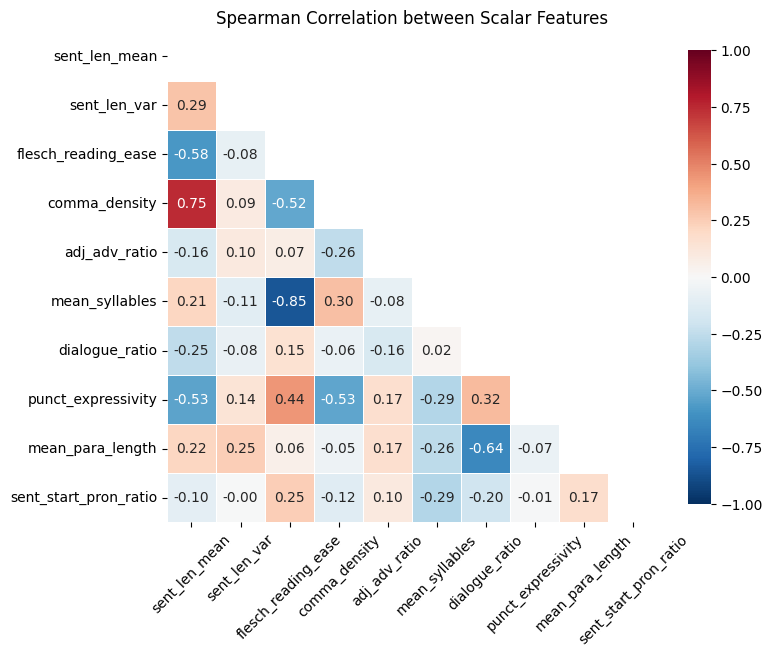


Highly correlated feature pairs (|r| > 0.6):
  flesch_reading_ease            <-> mean_syllables                  r = -0.853
  sent_len_mean                  <-> comma_density                   r = +0.748
  dialogue_ratio                 <-> mean_para_length                r = -0.642


In [64]:
corr_matrix = df_valid[scalar_feature_names].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title("Spearman Correlation between Scalar Features", fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("../../figures/stylistic_diversity/correlation_analysis")
plt.show()

# Flag high correlations (|r| > 0.6)
high_corr = []
for i in range(len(scalar_feature_names)):
    for j in range(i + 1, len(scalar_feature_names)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.6:
            high_corr.append((scalar_feature_names[i], scalar_feature_names[j], r))

print("\nHighly correlated feature pairs (|r| > 0.6):")
if high_corr:
    for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1:30s} <-> {f2:30s}  r = {r:+.3f}")
else:
    print("  None found — no feature pairs exceed |r| = 0.6")


In [52]:
# Remove redundant scalar features based on correlation analysis above:
#   flesch_reading_ease  removed — r = -0.853 with mean_syllables (nearly identical)
#   comma_density        removed — r = +0.748 with sent_len_mean (commas scale with sentence length)
#   mean_para_length     removed — r = -0.642 with dialogue_ratio (dialogue implies shorter paragraphs)
#

REDUNDANT_FEATURES = ['flesch_reading_ease', 'comma_density', 'mean_para_length']
scalar_features_reduced = [f for f in scalar_feature_names if f not in REDUNDANT_FEATURES]

print(f"All scalar features ({len(scalar_feature_names)}): {scalar_feature_names}")
print(f"\nRemoved as redundant: {REDUNDANT_FEATURES}")
print(f"\nFeatures used for D_style computation ({len(scalar_features_reduced)}):")
for f in scalar_features_reduced:
    print(f"  - {f}")

All scalar features (10): ['sent_len_mean', 'sent_len_var', 'flesch_reading_ease', 'comma_density', 'adj_adv_ratio', 'mean_syllables', 'dialogue_ratio', 'punct_expressivity', 'mean_para_length', 'sent_start_pron_ratio']

Removed as redundant: ['flesch_reading_ease', 'comma_density', 'mean_para_length']

Features used for D_style computation (7):
  - sent_len_mean
  - sent_len_var
  - adj_adv_ratio
  - mean_syllables
  - dialogue_ratio
  - punct_expressivity
  - sent_start_pron_ratio


## Compute D_style per Prompt × Source

1. 7 scalar features (after removing the 3 redundant ones identified above) are z-standardized within each prompt × source group
2. Compute pairwise distances -> D_style reflects relative variation rather than absolute scale differences across groups
3. Combine Function-word distribution feature via cosine distance and average with the standardized scalar-feature distance

In [53]:
def compute_d_style(group: pd.DataFrame, scalar_features: list):
    """
    Compute raw stylistic distance components for one (prompt_id, source) group.
    Returns:
      - mean pairwise Euclidean distance over z-standardized scalar features
      - mean pairwise cosine distance over function-word distributions
    Normalization and combination into D_style globally after all groups
    are computed, so both components can be scaled to the same range.
    """
    n = len(group)
    if n < 2:
        return 0.0, 0.0

    # 1. Scalar feature z-standardization (within group)
    scalar_matrix = group[scalar_features].values.astype(float)
    mu = scalar_matrix.mean(axis=0)
    sigma = scalar_matrix.std(axis=0)
    sigma[sigma == 0] = 1.0  # avoid div-by-zero for constant features
    z = (scalar_matrix - mu) / sigma

    pairs = list(combinations(range(n), 2))
    scalar_dists = [np.linalg.norm(z[i] - z[j]) for i, j in pairs]

    # 2. Function-word cosine distances
    fw_dists_arr = np.stack(group['fw_dist'].values)
    fw_dists = [cosine(fw_dists_arr[i], fw_dists_arr[j]) for i, j in pairs]
    fw_dists = [d if not np.isnan(d) else 0.0 for d in fw_dists]

    return np.mean(scalar_dists), np.mean(fw_dists)


# Compute raw components for each (prompt_id, source) pair
results = []
for (prompt_id, source), group in df_valid.groupby(['prompt_id', 'source']):
    scalar_part, fw_part = compute_d_style(group, scalar_features_reduced)
    results.append({
        'prompt_id': prompt_id,
        'source': source,
        'n_texts': len(group),
        'D_style_scalar_component': scalar_part,
        'D_style_funcword_component': fw_part,
    })

df_style = pd.DataFrame(results)

print(f"Computed D_style component values for {len(df_style)} (prompt, source) pairs")
print(f"\nRaw scalar component range: [{df_style['D_style_scalar_component'].min():.4f}, {df_style['D_style_scalar_component'].max():.4f}]")
print(f"Raw FW component range: [{df_style['D_style_funcword_component'].min():.4f}, {df_style['D_style_funcword_component'].max():.4f}]")


Computed D_style component values for 500 (prompt, source) pairs

Raw scalar component range: [2.6849, 3.8937]
Raw FW component range: [0.0405, 0.6364]


## Outlier Check (before Winsorized Min-Max Normalization)

Min-max normalization problematic if there are extreme observations; can compress the rest of distribution into a narrow band

D_style_scalar_component: bounds=[3.6314, 3.9450] (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
  -> 75 outlier(s) (15.0% of 500 observations)
D_style_funcword_component: bounds=[-0.0733, 0.3453] (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
  -> 15 outlier(s) (3.0% of 500 observations)

Scalar component outliers:


,prompt_id,source,D_style_scalar_component
159,31,qwen,2.684888
157,31,llama,3.024117
452,90,llama,3.122268
155,31,gemma,3.145220
443,88,mistral,3.188063
...,...,...,...
189,37,qwen,3.575516
263,52,mistral,3.577127
66,13,human,3.589744
296,59,human,3.593903



Function-word component outliers:


,prompt_id,source,D_style_funcword_component
446,89,human,0.345518
401,80,human,0.345754
406,81,human,0.348955
146,29,human,0.350893
411,82,human,0.357646
61,12,human,0.358247
336,67,human,0.366703
155,31,gemma,0.385226
386,77,human,0.394428
241,48,human,0.408582


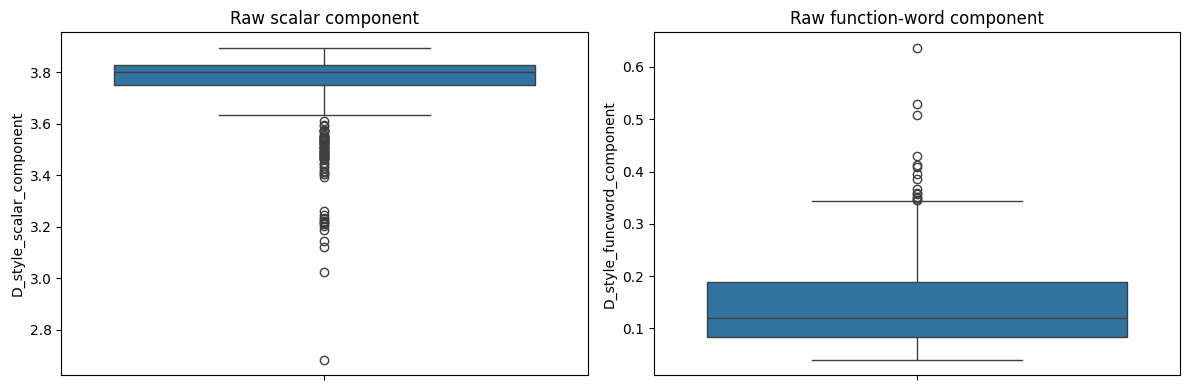

In [54]:
def iqr_bounds(series: pd.Series, k: float = 1.5) -> tuple[float, float]:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def report_outliers(df: pd.DataFrame, col: str, k: float = 1.5) -> pd.DataFrame:
    lower, upper = iqr_bounds(df[col], k)
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: bounds=[{lower:.4f}, {upper:.4f}] (Q1 - {k}*IQR, Q3 + {k}*IQR)")
    print(f"  -> {len(outliers)} outlier(s) ({len(outliers) / len(df):.1%} of {len(df)} observations)")
    return outliers.sort_values(col)[['prompt_id', 'source', col]]

scalar_outliers = report_outliers(df_style, 'D_style_scalar_component')
fw_outliers = report_outliers(df_style, 'D_style_funcword_component')

print("\nScalar component outliers:")
display(scalar_outliers)
print("\nFunction-word component outliers:")
display(fw_outliers)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df_style['D_style_scalar_component'], ax=axes[0])
axes[0].set_title('Raw scalar component')
sns.boxplot(y=df_style['D_style_funcword_component'], ax=axes[1])
axes[1].set_title('Raw function-word component')
plt.tight_layout()
plt.savefig("../../figures/stylistic_diversity/d_style_boxplots_outliers_before")
plt.show()


-> Scalar-Component: 15% percent are outliers, all on the lower bound and mostly AI-stories  
-> Function-Word-Component: 3.0% are outliers, all on the upper bound and mostly human stories

In [55]:
# Winsorize both components at (Q1 - 1.5*IQR, Q3 + 1.5*IQR), then min-max normalize to [0,1].

def winsorized_minmax(series: pd.Series, k: float = 1.5) -> pd.Series:
    # Get IQR bounds
    lower, upper = iqr_bounds(series, k)
    # Clip values outside the bounds
    clipped = series.clip(lower, upper)
    # Min-max normalize to [0,1]
    return (clipped - clipped.min()) / (clipped.max() - clipped.min())

df_style['scalar_norm'] = winsorized_minmax(df_style['D_style_scalar_component'])
df_style['fw_norm']     = winsorized_minmax(df_style['D_style_funcword_component'])
df_style['D_style']     = 0.5 * df_style['scalar_norm'] + 0.5 * df_style['fw_norm']

print(f"Normalized scalar range: [{df_style['scalar_norm'].min():.4f}, {df_style['scalar_norm'].max():.4f}]")
print(f"Normalized FW range: [{df_style['fw_norm'].min():.4f}, {df_style['fw_norm'].max():.4f}]")
df_style.groupby('source')['D_style'].describe().round(4)


Normalized scalar range: [0.0000, 1.0000]
Normalized FW range: [0.0000, 1.0000]


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
gemma,100.0,0.4479,0.1401,0.0183,0.4008,0.4676,0.5164,0.7365
human,100.0,0.5458,0.1829,0.0920,0.4117,0.5644,0.6754,0.8988
llama,100.0,0.4391,0.1161,0.0478,0.3835,0.4387,0.5051,0.7215
mistral,100.0,0.3370,0.1924,0.0000,0.1527,0.3868,0.4875,0.8014
qwen,100.0,0.4641,0.1463,0.0004,0.4045,0.4742,0.5397,0.7742


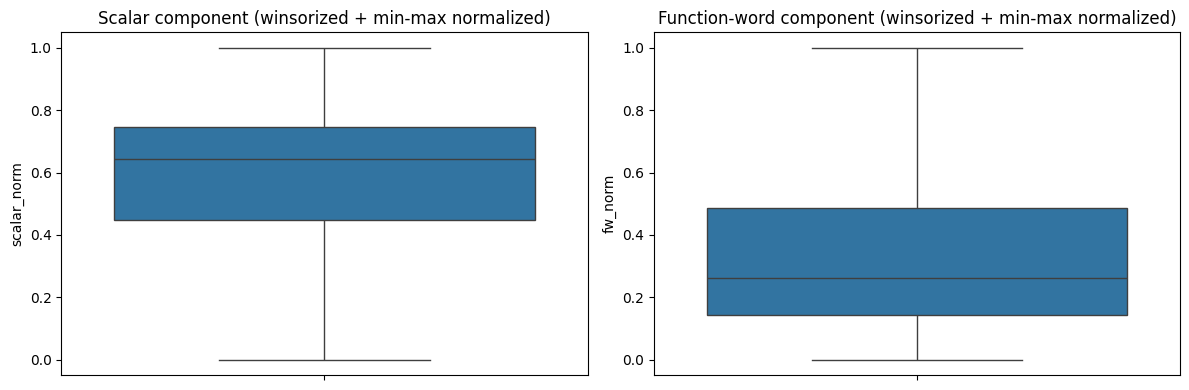

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df_style['scalar_norm'], ax=axes[0])
axes[0].set_title('Scalar component (winsorized + min-max normalized)')
sns.boxplot(y=df_style['fw_norm'], ax=axes[1])
axes[1].set_title('Function-word component (winsorized + min-max normalized)')
plt.tight_layout()
plt.savefig("../../figures/stylistic_diversity/d_style_boxplots_outliers_after")
plt.show()


## Descriptive Analysis

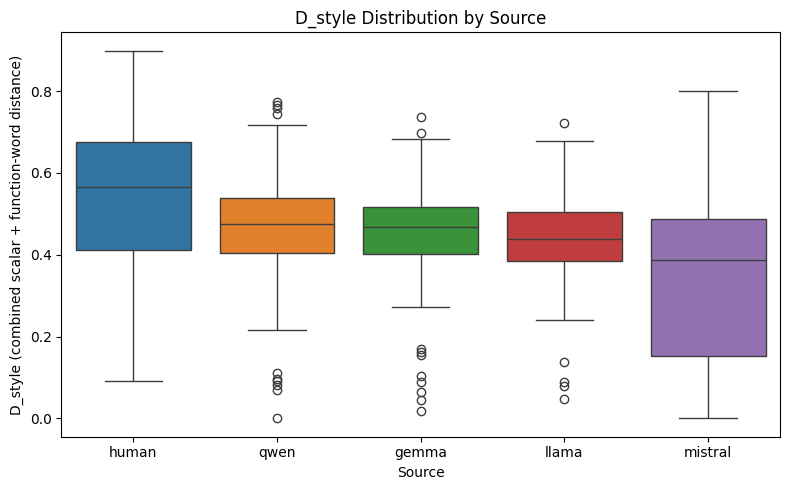

,mean,std
source,,
human,0.5458,0.1829
qwen,0.4641,0.1463
gemma,0.4479,0.1401
llama,0.4391,0.1161
mistral,0.3370,0.1924


In [65]:
fig, ax = plt.subplots(figsize=(8, 5))

source_order = df_style.groupby('source')['D_style'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df_style, x='source', y='D_style', order=source_order, palette='tab10', ax=ax)
ax.set_title('D_style Distribution by Source', fontsize=12)
ax.set_xlabel('Source')
ax.set_ylabel('D_style (combined scalar + function-word distance)')

plt.tight_layout()
plt.savefig("../../figures/stylistic_diversity/d_style_boxplots_combined")
plt.show()

df_style.groupby('source')['D_style'].agg(['mean', 'std']).reindex(source_order).round(4)


## Component Breakdown

Compare the function-word component vs. the scalar-feature component to see which drives D_style per source

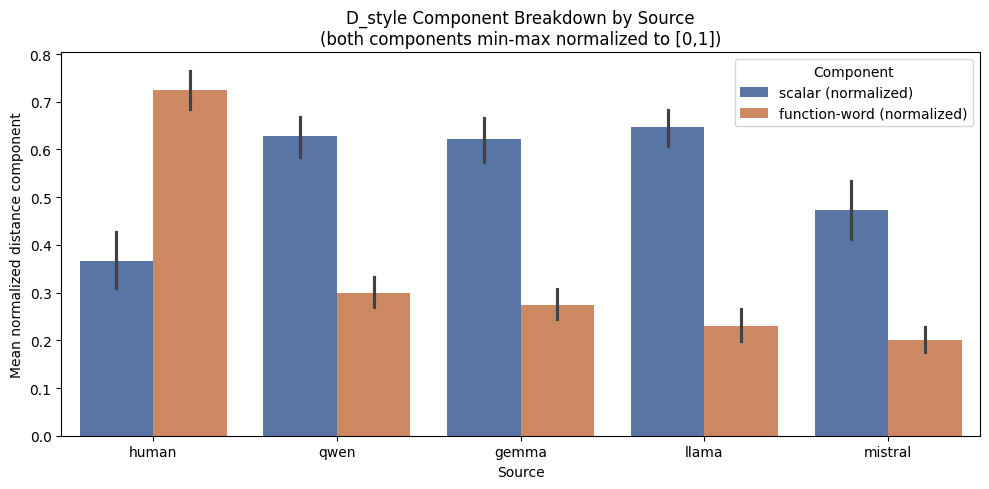

In [58]:
component_df = df_style.melt(
    id_vars=['prompt_id', 'source'],
    value_vars=['scalar_norm', 'fw_norm'],
    var_name='component', value_name='value'
)
component_df['component'] = component_df['component'].map({
    'scalar_norm': 'scalar (normalized)',
    'fw_norm':     'function-word (normalized)'
})

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=component_df, x='source', y='value', hue='component',
            order=source_order, ax=ax, palette=['#4C72B0', '#DD8452'])
ax.set_title('D_style Component Breakdown by Source\n(both components min-max normalized to [0,1])', fontsize=12)
ax.set_xlabel('Source')
ax.set_ylabel('Mean normalized distance component')
ax.legend(title='Component')
plt.tight_layout()
plt.savefig("../../figures/stylistic_diversity/d_style_component_breakdown")
plt.show()

## Individual Feature Distributions

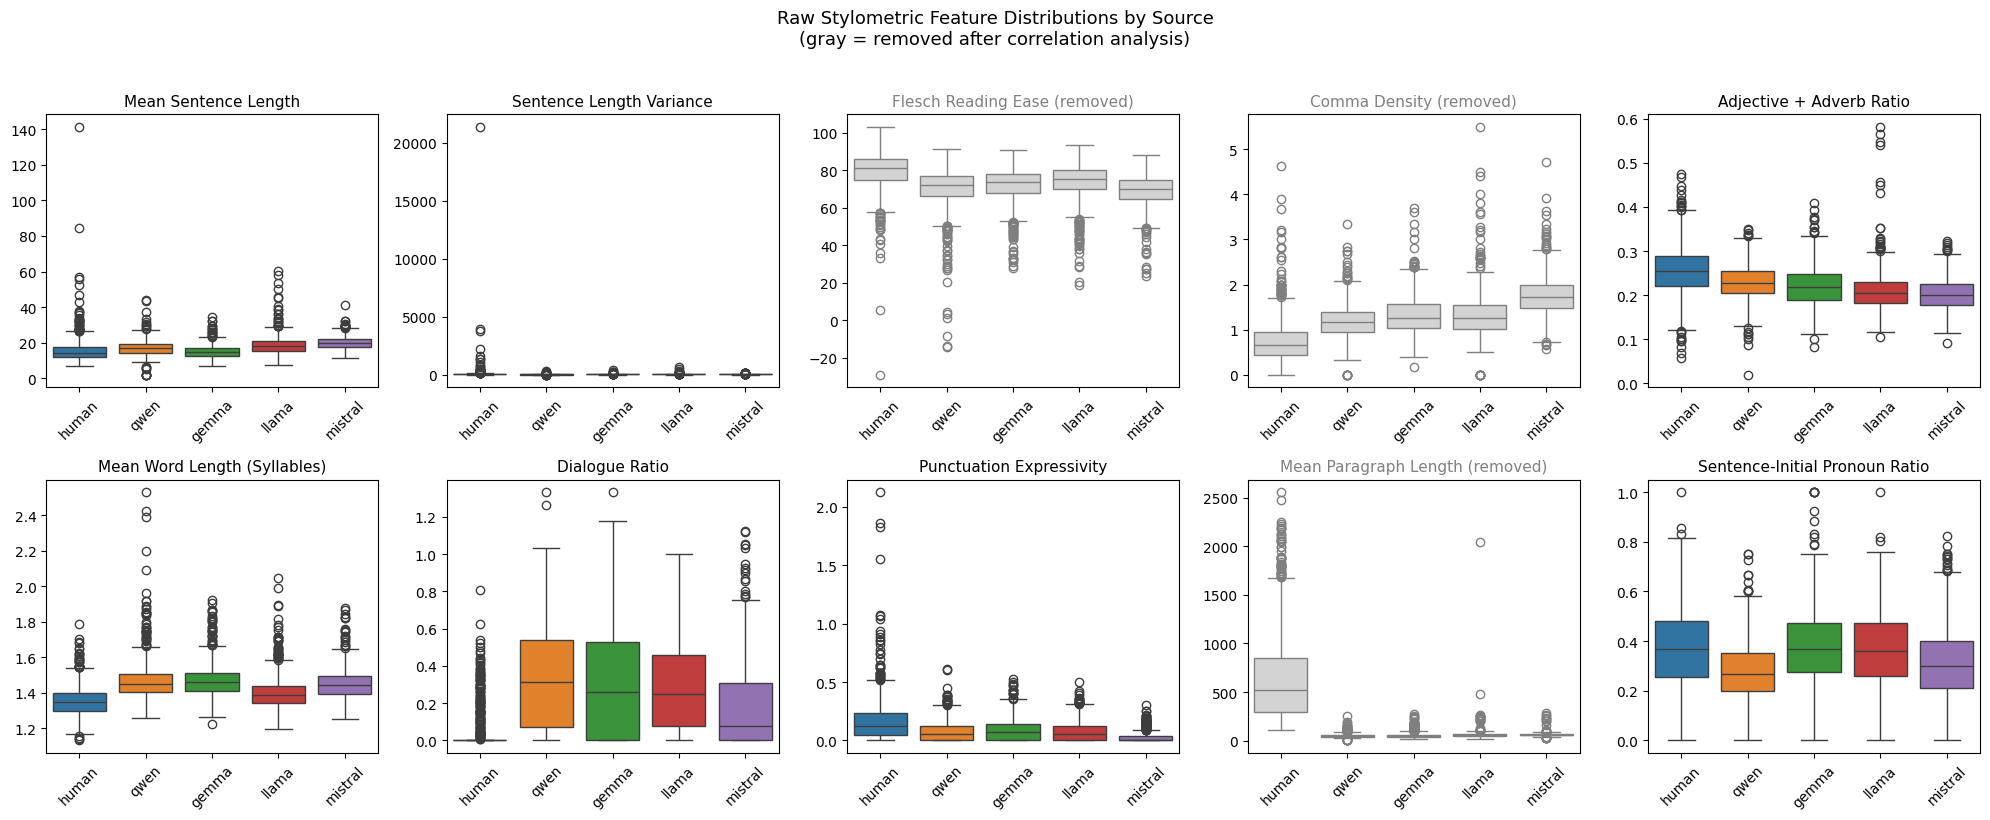

In [59]:
n_features = len(scalar_feature_names)
n_cols = 5
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for ax, fname in zip(axes, scalar_feature_names):
    is_removed = fname in REDUNDANT_FEATURES
    palette = ['lightgray'] * len(source_order) if is_removed else 'tab10'
    sns.boxplot(data=df_valid, x='source', y=fname, order=source_order, palette=palette, ax=ax)
    label = FEATURE_LABELS[fname]
    title_kwargs = {'color': 'gray'} if is_removed else {}
    ax.set_title(f'{label} (removed)' if is_removed else label, fontsize=11, **title_kwargs)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45)

# Hide any unused subplots
for ax in axes[n_features:]:
    ax.set_visible(False)

fig.suptitle('Raw Stylometric Feature Distributions by Source\n(gray = removed after correlation analysis)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../figures/stylistic_diversity/raw_stylometric_features_by_source")
plt.show()


## Statistical Testing: Does Source Affect D_style?

In [60]:
from itertools import combinations as combos

groups = [df_style[df_style['source'] == s]['D_style'].values for s in SOURCES]

stat, p = kruskal(*groups)
print("Kruskal-Wallis test across sources:")
print(f"  H = {stat:.4f}, p = {p:.4f}")
if p < 0.05:
    print("  -> Significant difference in D_style across sources (p < 0.05)")
else:
    print("  -> No significant difference detected (p >= 0.05)")

print("\nPairwise Mann-Whitney U tests (Bonferroni corrected):")
pairs = list(combos(SOURCES, 2))
alpha_corrected = 0.05 / len(pairs)
print(f"  Bonferroni threshold: p < {alpha_corrected:.4f}")

for s1, s2 in pairs:
    g1 = df_style[df_style['source'] == s1]['D_style'].values
    g2 = df_style[df_style['source'] == s2]['D_style'].values
    u, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
    sig = '***' if p_mw < alpha_corrected else ('*' if p_mw < 0.05 else 'ns')
    print(f"  {s1:10s} vs {s2:10s}: U={u:.0f}, p={p_mw:.4f}  {sig}")

Kruskal-Wallis test across sources:
  H = 60.6682, p = 0.0000
  -> Significant difference in D_style across sources (p < 0.05)

Pairwise Mann-Whitney U tests (Bonferroni corrected):
  Bonferroni threshold: p < 0.0050
  human      vs llama     : U=6900, p=0.0000  ***
  human      vs mistral   : U=7801, p=0.0000  ***
  human      vs qwen      : U=6390, p=0.0007  ***
  human      vs gemma     : U=6676, p=0.0000  ***
  llama      vs mistral   : U=6392, p=0.0007  ***
  llama      vs qwen      : U=4187, p=0.0471  *
  llama      vs gemma     : U=4520, p=0.2418  ns
  mistral    vs qwen      : U=3080, p=0.0000  ***
  mistral    vs gemma     : U=3350, p=0.0001  ***
  qwen       vs gemma     : U=5330, p=0.4208  ns


## Weighting Sensitivity Analysis

- No strong theoretical justification for 0.5/0.5 split between the scalar and function-word component
- Treats two stylistic components as equally important by default.
- Recompute D_style under alternative weightings and check whether the Kruskal-Wallis / Mann-Whitney conclusions above stay the same

In [61]:
# Scalar-component weight; fw weight = 1 - w
WEIGHTS = [0.3, 0.5, 0.7]

sensitivity_results = []
pairwise_pvals = {}

# Vary the weights of the scalar and function-word components
for w in WEIGHTS:
    # Compute weighted D_style for each (prompt_id, source) pair
    d_style_w = w * df_style['scalar_norm'] + (1 - w) * df_style['fw_norm']
    groups_w = [d_style_w[df_style['source'] == s].values for s in SOURCES]
    stat, p_kw = kruskal(*groups_w)
    sensitivity_results.append({'scalar_weight': w, 'fw_weight': round(1 - w, 2), 'KW_H': stat, 'KW_p': p_kw})

    # Pairwise Mann-Whitney U tests for each source pair
    for s1, s2 in pairs:
        g1 = d_style_w[df_style['source'] == s1].values
        g2 = d_style_w[df_style['source'] == s2].values
        _, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
        pairwise_pvals.setdefault((s1, s2), {})[w] = p_mw

sensitivity_df = pd.DataFrame(sensitivity_results)
print("Kruskal-Wallis across weightings:")
display(sensitivity_df)

pairwise_df = pd.DataFrame(pairwise_pvals).T
pairwise_df.columns = [f'w={w}' for w in pairwise_df.columns]
pairwise_df.index = [f'{s1} vs {s2}' for s1, s2 in pairwise_df.index]

sig_df = pairwise_df < alpha_corrected
print(f"\nSignificant at Bonferroni threshold p < {alpha_corrected:.4f}:")
display(sig_df)


Kruskal-Wallis across weightings:


,scalar_weight,fw_weight,KW_H,KW_p
0,0.3,0.7,160.531341,1.124525e-33
1,0.5,0.5,60.668195,2.099356e-12
2,0.7,0.3,22.390168,1.675798e-04



Significant at Bonferroni threshold p < 0.0050:


,w=0.3,w=0.5,w=0.7
human vs llama,True,True,False
human vs mistral,True,True,False
human vs qwen,True,True,False
human vs gemma,True,True,False
llama vs mistral,True,True,True
llama vs qwen,False,False,False
llama vs gemma,False,False,False
mistral vs qwen,True,True,True
mistral vs gemma,True,True,True
qwen vs gemma,False,False,False


## Component Breakdown of Weighting-Sensitive Pairs

The weighting-sensitive pairs identified above don't reflect noise — they reflect the
scalar and function-word components disagreeing about whether those sources differ.
Test each component on its own (instead of blending them into one scalar D_style) to
show explicitly which stylistic dimension drives which pairwise difference.

Note: which pairs turn out to be sensitive depends on the underlying features — e.g.
switching the function-word list from the hand-picked 50 words to the full NLTK
stopword list changed `human vs mistral` from a robust (weighting-independent) result
to a weighting-sensitive one. The list below is therefore derived programmatically
from the sensitivity analysis (`sig_df`) rather than hardcoded, so it stays correct
across reruns.

In [62]:
def component_kw_mw(df: pd.DataFrame, col: str) -> pd.DataFrame:
    '''
    Perform Kruskal-Wallis test and pairwise Mann-Whitney U tests for a given component column.
    Returns a DataFrame with pairwise p-values and significance flags.
    '''
    # Kruskal-Wallis test across all sources
    groups_c = [df[df['source'] == s][col].values for s in SOURCES]
    stat, p_kw = kruskal(*groups_c)
    print(f"{col}: Kruskal-Wallis H={stat:.4f}, p={p_kw:.4g}")

    # Pairwise Mann-Whitney U tests
    rows = []
    for s1, s2 in pairs:
        g1 = df[df['source'] == s1][col].values
        g2 = df[df['source'] == s2][col].values
        _, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
        rows.append({'pair': f'{s1} vs {s2}', col: p_mw, f'{col}_sig': p_mw < alpha_corrected})
    return pd.DataFrame(rows).set_index('pair')

scalar_breakdown = component_kw_mw(df_style, 'scalar_norm')
fw_breakdown = component_kw_mw(df_style, 'fw_norm')

breakdown_df = scalar_breakdown.join(fw_breakdown)
print()
display(breakdown_df.round(4))

# Pairs whose significance flips across the weightings tested in the sensitivity
# analysis above (derived from sig_df, not hardcoded, so this stays correct if the
# underlying features change and the sensitive pairs shift)
unstable_pairs = sig_df.index[sig_df.nunique(axis=1) > 1].tolist()
print(f"\nWeighting-sensitive pairs ({len(unstable_pairs)}), explained by component:")
for pair in unstable_pairs:
    row = breakdown_df.loc[pair]
    print(f"  {pair}: scalar {'sig' if row['scalar_norm_sig'] else 'ns'} (p={row['scalar_norm']:.4f})"
          f"  |  function-word {'sig' if row['fw_norm_sig'] else 'ns'} (p={row['fw_norm']:.4f})")


scalar_norm: Kruskal-Wallis H=69.4760, p=2.928e-14
fw_norm: Kruskal-Wallis H=216.4034, p=1.114e-45



,scalar_norm,scalar_norm_sig,fw_norm,fw_norm_sig
pair,,,,
human vs llama,0.0000,True,0.0000,True
human vs mistral,0.0052,False,0.0000,True
human vs qwen,0.0000,True,0.0000,True
human vs gemma,0.0000,True,0.0000,True
llama vs mistral,0.0004,True,0.3339,False
llama vs qwen,0.8854,False,0.0006,True
llama vs gemma,0.9406,False,0.0051,False
mistral vs qwen,0.0015,True,0.0000,True
mistral vs gemma,0.0010,True,0.0003,True



Weighting-sensitive pairs (4), explained by component:
  human vs llama: scalar sig (p=0.0000)  |  function-word sig (p=0.0000)
  human vs mistral: scalar ns (p=0.0052)  |  function-word sig (p=0.0000)
  human vs qwen: scalar sig (p=0.0000)  |  function-word sig (p=0.0000)
  human vs gemma: scalar sig (p=0.0000)  |  function-word sig (p=0.0000)


## Export Results

In [63]:
out_path = 'D_style_results.csv'

# Summary: only prompt_id, source, n_texts, D_style
df_style[['prompt_id', 'source', 'n_texts', 'D_style']].to_csv(
    out_path.replace('.csv', '_summary.csv'), index=False
)

# Full: include raw and normalized components for transparency
df_style.to_csv(out_path, index=False)

print(f"Saved D_style results to: {out_path}")
df_style.head(10)

Saved D_style results to: D_style_results.csv


,prompt_id,source,n_texts,D_style_scalar_component,D_style_funcword_component,scalar_norm,fw_norm,D_style
0,0,gemma,10,3.791130,0.068241,0.609040,0.091024,0.350032
1,0,human,10,3.814497,0.260190,0.698130,0.720755,0.709442
2,0,llama,10,3.772624,0.083287,0.538487,0.140387,0.339437
3,0,mistral,10,3.778128,0.062410,0.559472,0.071895,0.315683
4,0,qwen,10,3.812193,0.100363,0.689346,0.196406,0.442876
5,1,gemma,10,3.813917,0.125837,0.695919,0.279982,0.487950
6,1,human,10,3.773072,0.190097,0.540194,0.490801,0.515497
7,1,llama,10,3.768212,0.099901,0.521664,0.194893,0.358278
8,1,mistral,10,3.815009,0.063827,0.700082,0.076542,0.388312
9,1,qwen,10,3.791774,0.145205,0.611497,0.343523,0.477510
